---
format:
  html:
    code-fold: true
    code-summary: "Mostrar código"
---

# Práctica 2. Análisis de los rendimientos en fabricación de queso mediante `Python`

---

***Documento en elaboración***

---

En esta práctica utilizaremos un conjunto de datos que provienen de una fábrica de queso tipo ibérico. Con los valores analíticos calcularemos los rendimientos queseros utilizando Python, y nos apoyaremos en diferentes tipos de gráficos para explicar los resultados que hemos obtenido. Utilizaremos los datos calculados aquí para hacer un balance de materia y calcular las pérdidas de nuestra fabricación. 

Para ayudar a concentrarse en los resultados, el código *python* se presenta plegado, de manera que no interfiera demasiado en la presentación. Puede desplegarse para ver cómo se han generado cada tabla y cada gráfico.

Como siempre, es opcional descargar los datos de ejemplo y abrir el cuaderno en Colab para ejecutar el código a medida que se avanza ne el estudio.

[Abrir este cuaderno en Google Colab](https://colab.research.google.com/github/juanriera/master-queseria/blob/master/090-pract02-rendimientos.ipynb){target="_blank" rel="noopener noreferrer"}

[Descargar los datos de ejemplo utilizados en este cuaderno (archivo `fab_queso_bm.csv`)](https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm.csv){target="_blank" rel="noopener noreferrer"}

Empezamos el análisis inicializando las bibliotecas de `Python`, cargamos los datos del `CSV`, creamos el índice de fecha y mostramos los primeros registros del dataframe para comprobar que todo es correcto.

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

url_datos = 'https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm.csv'

try:
    df = pd.read_csv(url_datos, decimal = ",", sep=';', encoding='ISO-8859-1')
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

# crear index con fecha
df['fecha_index'] = pd.to_datetime(
    df['fecha'], 
    format='%d/%m/%Y',  # Formato Día/Mes/Año confirmado
    errors='coerce'     # Clave: convierte los valores que no puede leer a NaT (Not a Time)
)
# 2. Limpiar NaT y establecer el índice
df.dropna(subset=['fecha_index'], inplace=True)
df.set_index('fecha_index', inplace=True)
df.sort_index(inplace=True)

df.head()

,fecha,receta,litros_past,est_past,mg_past,mp_past,kg_cuba,est_cuba,mg_cuba,mp_cuba,lactosa_cuba,ph_final_moldeo_cuba,formato,est_salida_salmuera,mg_salida_salmuera,ph_salida_salmuera,peso_queso_total,sal_queso
fecha_index,,,,,,,,,,,,,,,,,,
2022-02-23,23/02/2022,bajo mg,12380,10.76,2.58,3.55,12860.510,10.28,2.46,3.38,4.44,6.46,3 kg,50.85,20.34,5.44,1419.3,1.47
2022-02-24,24/02/2022,mezcla,7440,13.29,5.15,4.09,7704.462,12.80,4.90,3.89,4.01,6.35,barra,59.42,32.13,5.40,1062.4,1.31
2022-03-01,01/03/2022,bajo mg,13080,11.09,2.59,3.60,13867.370,10.41,2.47,3.43,4.51,6.40,barra,52.10,21.15,5.34,1536.0,1.17
2022-03-01,01/03/2022,vaca,14910,14.00,5.27,4.17,15810.990,12.85,5.03,3.97,3.85,6.38,barra,55.94,30.50,5.41,2351.0,1.55
2022-03-04,04/03/2022,oveja,11760,14.99,6.16,4.79,12344.190,14.37,5.86,4.55,3.96,6.42,barra,57.60,31.99,5.42,2051.0,NaN


En total, tenemos 45 entradas que corresponden a fabricaciones diarias, desde el 23/02/2022 hasta el 30/5/2022. 

El fichero de datos incluye diferentes datos analíticos:

| Columna | Descripción |
|--------|----------------|
| **fecha**  | día de fabricación |
| **receta** | tipo de queso fabricado |
| **litros_past** | litros de leche enviados a pasteurización|
| **kg_cuba** | cantidad de leche recibida en cuba, en kilos |
| **est_cuba** | extracto seco de la leche en la cuba|
| **mg_cuba** | materia grasa de la leche en la cuba|
| **mp_cuba** | materia proteica de la leche en la cuba |
| **lactosa_cuba** | lactosa de la leche en la cuba |
| **ph_final_moldeo_cuba** | pH del queso al final del proceso de moldeo|
| **formato** | formato de moldeo |
| **est_salida_salmuera** | extracto seco total del queso después del salado |
| **mg_salida_salmuera** | materia grasa del queso después del salado |
| **ph_salida_salmuera** | pH del queso después del salado|
| **peso_queso_total** | peso del queso después del salado |
| **sal_queso** | porcentaje de sal analizada en el queso|

El queso se fabrica en varias recetas, y se envasa en diferentes formatos:

| Receta           | Formatos              | Comentario                          |
|------------------|-----------------------|-------------------------------------|
| i+D (ensayos)    | 3 kg, 500 g, barra    |                                     |
| bajo mg          | 3 kg, 500 g, barra    | Queso con bajo contenido en MG      |
| mezcla           | 3 kg, 500 g, barra    |                                     |
| oveja            | barra                 |                                     |
| vaca             | barra                 |                                     |


El fichero de datos contiene varios ensayos del departamento de i+D que se han mantenido para mostrar que a veces las cosas no salen bien a la primera...

In [61]:
#| include: false
#| echo: false
#| eval: false

# este código simplemente formatea algunos datos en markdown para preparar el documento 
# y no se usa en el análisis
def info_as_markdown(df):
    summary = pd.DataFrame({
        "Column": df.columns,
        "Non-Null Count": df.count(),
        "Null Count": df.isnull().sum(),
        "Dtype": df.dtypes.astype(str)
    }).reset_index(drop=True)

    markdown = "| Column | Non-Null Count | Null Count | Dtype |\n"
    markdown += "|--------|----------------|------------|-------|\n"
    for _, row in summary.iterrows():
        markdown += f"| {row['Column']} | {row['Non-Null Count']} | {row['Null Count']} | {row['Dtype']} |\n"
    return markdown

# print(info_as_markdown(df))

def tabla_agrupada_markdown(df):
    agrupado = df.groupby('receta')['formato'].apply(lambda x: ', '.join(sorted(set(x)))).reset_index()
    markdown = "| Receta | Formatos |\n"
    markdown += "|--------|----------|\n"
    for _, row in agrupado.iterrows():
        markdown += f"| {row['receta']} | {row['formato']} |\n"
    return markdown

# print(tabla_agrupada_markdown(df))

## Exploración gráfica de los datos

Vamos a explorar los datos antes de empezar el análisis, y los usaremos para visualizar las diferencias de rendimiento entre mezclas.

Podemos calcular el rendimiento simple como los kilos de queso que podemos obtener con 100 L de leche

In [62]:
#| code-fold: false

df['rendimiento_simple'] = df['peso_queso_total']/df['litros_past']*100

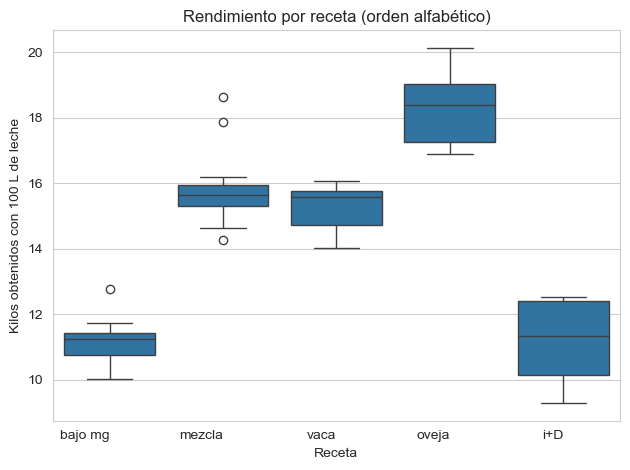

In [63]:
sns.boxplot(data=df, x='receta', y='rendimiento_simple')
plt.xticks(rotation=0, ha='right')
plt.title('Rendimiento por receta (orden alfabético)')
plt.xlabel('Receta')
plt.ylabel('Kilos obtenidos con 100 L de leche')
plt.tight_layout()
plt.show()


Aunque es más frecuente calcular el rendimiento simple como los litros de leche que necesitamos para hacer un kilo de queso

In [64]:
#| code-fold: false

df['rendimiento_simple'] = df['litros_past']/df['peso_queso_total']

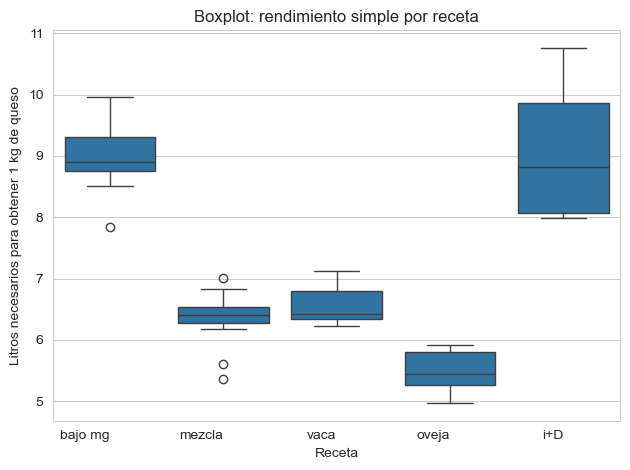

In [65]:
sns.boxplot(data=df, x='receta', y='rendimiento_simple')
plt.xticks(rotation=0, ha='right')
plt.title('Boxplot: rendimiento simple por receta')
plt.xlabel('Receta')
plt.ylabel('Litros necesarios para obtener 1 kg de queso')
plt.tight_layout()
plt.show()

## Análisis previo de los datos

Tenemos pocos datos por receta, por lo que vamos a utilizar el *beeswarm*, junto con el *boxplot*, para visualizar el *rendimiento simple* entre las diferentes recetas. 

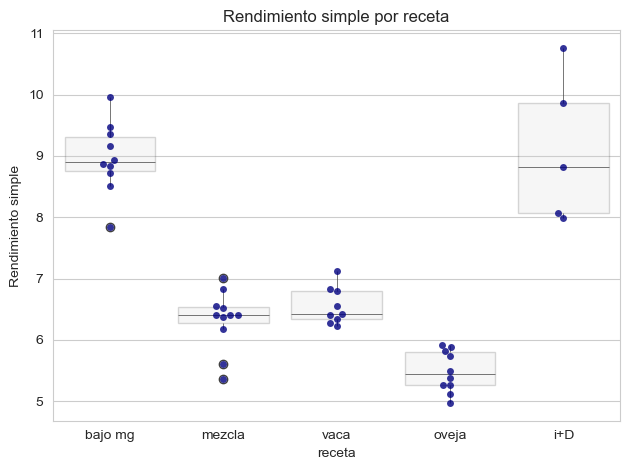

In [66]:
# Boxplot como fondo tenue
sns.boxplot(
    data=df,
    x='receta',
    y='rendimiento_simple',
    boxprops=dict(facecolor='lightgray', alpha=0.2),  # gris claro y muy transparente
    showcaps=False,
    whiskerprops={'linewidth': 0.5},
    medianprops={'linewidth': 0.5}
)

# Beeswarm destacado encima
sns.swarmplot(
    data=df,
    x='receta',
    y='rendimiento_simple',
    size=5,
    color='navy',  # color fuerte y contrastante
    alpha=0.8  # casi opaco para destacar
)

# Estética general
plt.xticks(rotation=0)
plt.title('Rendimiento simple por receta')
plt.ylabel('Rendimiento simple')
plt.tight_layout()
plt.show()

Como estamos evaluando el rendimiento como los litros necesarios para obtener 1 kg de queso, resulta que la cantidad de agua que tenga el queso nos influye en el cálculo: cuanto más húmedo el queso, más favorable será el valor el rendimiento simple. Fijémonos en el queso de mezcla: hay un valor de rendimiento muy favorable, de poco más de 5 L/kg de queso, pero vemos que el queso ha tenido casi un 52% de humedad. En cambio, otra fabricación de esa misma receta, que sólo tiene algo más de 40% de humedad, ha necesitado 7 L/kg. 

Así, dentro de cada receta, los mejores rendimientos en L/kg aparecen siempre en quesos más húmedos, y los peores, en quesos más secos. Veámoslo creando una columna adicional para los valores d humedad.

In [67]:
#| code-fold: false

# Crear columna de humedad
df['humedad_salida_salmuera'] = 100 - df['est_salida_salmuera']

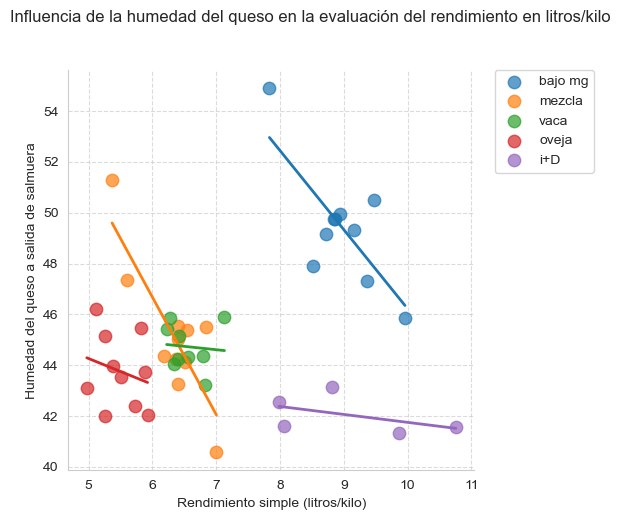

In [68]:
# crear dataframe para seaborn sin index para evitar errores
df_plot_sns = df.reset_index(drop=True)

# Crear gráfico con regresión lineal por receta
g = sns.lmplot(
    data=df_plot_sns,
    x='rendimiento_simple',
    y='humedad_salida_salmuera',
    hue='receta',
    ci=None,
    scatter_kws={'s': 80, 'alpha': 0.7},
    line_kws={'linewidth': 2}
)

# Eliminar la leyenda generada por FacetGrid
g._legend.remove()

# Personalizar título y ejes
g.fig.suptitle('Influencia de la humedad del queso en la evaluación del rendimiento en litros/kilo', y=1.03)
g.set_axis_labels('Rendimiento simple (litros/kilo)', 'Humedad del queso a salida de salmuera')
g.ax.grid(True, linestyle='--', alpha=0.7)

# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()



CLaramente, el rendimiento en litros/kilo está afectado por la humedad del queso, ya que, para la misma tecnología, cuanta más humedad más peso tendremos en el queso, y en consecuencia, menos litros necesitaremos para hacer un kilo de queso.

Por esta razón, como hemos visto en el capitulo anterior, debemos calcular el rendimiento mediante parámetros que no se vean afectados por la humedad del queso (o lo que es equivalente, el extracto seco total), sino que reflejen con precisión la calidad del trabajo quesero. La mejor forma de hacerlo consiste en calcular el porcentaje de materia quesera que hemos sido capaces de retener en el queso. Dado que los elementos de valor de la leche, que son los que se utilizan en el pago por calidad, son la materia grasa y la proteína, calcularemos la recuperación de materia grasa, de materia proteica y de extracto seco magro. 

Estos valores son propios de cada tecnología quesera, y cada uno sirve de referencia para comprender cuáles son los diferentes problemas en fabricación, 

* Una mala retención de materia grasa
* Una mala retención de proteína
* Una mala retención de extracto seco magro

Dado que nuestros valores analíticos están expresados en porcentaje en peso, calculamos las cantidades de materia como se indica a continuación:

In [ ]:
#| code-fold: false

### 1. Cálculos de pasteurizacion
df['est_kg_past'] = df['litros_past'] * df['est_past'] / 100
df['mg_kg_past'] = df['litros_past'] * df['mg_past'] / 100
df['mp_kg_past'] = df['litros_past'] * df['mp_past'] / 100
df['esm_kg_past'] = df['est_kg_past'] - df['mg_kg_past'] 

### 1. Cálculos de cuba
df['est_kg_cuba'] = df['kg_cuba'] * df['est_cuba'] / 100
df['mg_kg_cuba'] = df['kg_cuba'] * df['mg_cuba'] / 100
df['mp_kg_cuba'] = df['kg_cuba'] * df['mp_cuba'] / 100
df['esm_kg_cuba'] = df['est_kg_cuba'] - df['mg_kg_cuba'] 

### 2. Cálculos de queso
df['est_kg_queso'] = df['peso_queso_total'] * df['est_salida_salmuera'] / 100
df['mg_kg_queso'] = df['peso_queso_total'] * df['mg_salida_salmuera'] / 100
df['esm_kg_queso'] = df['est_kg_queso'] - df['mg_kg_queso']
df['sal_kg_queso'] = df['peso_queso_total'] * df['sal_queso']/100

### 3. Coeficientes de recuperación (expresado en porcentaje)
df['coef_recup_mg']  = df['mg_kg_queso']/df['mg_kg_cuba'] * 100
df['coef_recup_mp']  = df['esm_kg_queso']/df['mp_kg_cuba'] * 100 # atencion a la fórmula de cálculo, deberia ser mp_kg_queso
df['coef_recup_esm'] = df['esm_kg_queso']/df['esm_kg_cuba'] * 100

### 4. Consumos de materia por kilo de queso (expresado en gramos de materia por kilo de queso)
df['consumo_mg_kg'] = df['mg_kg_cuba'] / df['peso_queso_total'] * 1000
df['consumo_mp_kg'] = df['mp_kg_cuba'] / df['peso_queso_total'] * 1000

### 5. Otros cálculos: relación MG/MP en la leche de entrada y en el queso
df['ratio_mg_mp_leche']  = df['mg_kg_cuba'] / df['mp_kg_cuba']
df['ratio_mg_esm_leche'] = df['mg_kg_cuba'] / df['esm_kg_cuba']
df['ratio_mg_esm_queso'] = df['mg_kg_queso'] / df['esm_kg_queso']

### 6. Otros coeficientes: HQD y G/ES
df['hqd_salida_salmuera'] = (100 - df['est_salida_salmuera']) / (100 - df['mg_salida_salmuera']) * 100
df['ges_salida_salmuera'] = df['mg_salida_salmuera'] / df['est_salida_salmuera'] * 100

Comparemos ahora la recuperación de materia medida por estos coeficientes entre recetas.

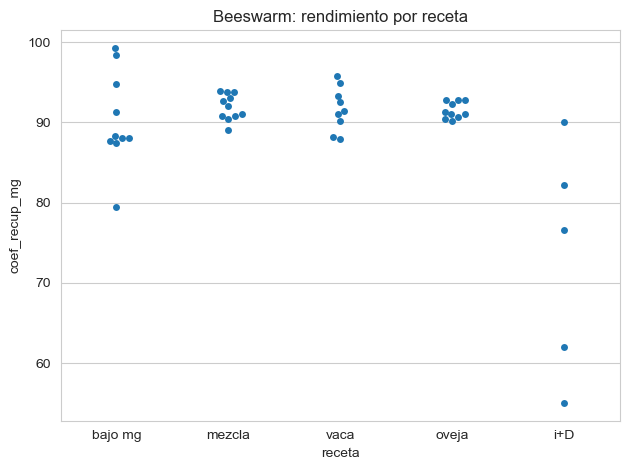

In [70]:
# crear dataframe para seaborn sin index para evitar errores
df_sns = df.reset_index(drop=True)

sns.swarmplot(data=df_sns, x='receta', y='coef_recup_mg', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

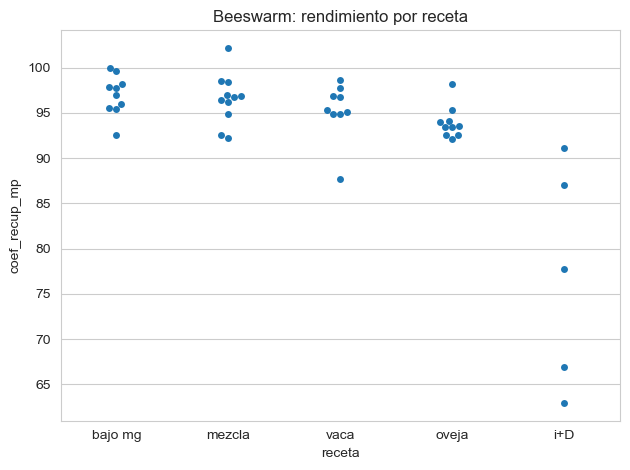

In [71]:
sns.swarmplot(data=df_sns, x='receta', y='coef_recup_mp', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

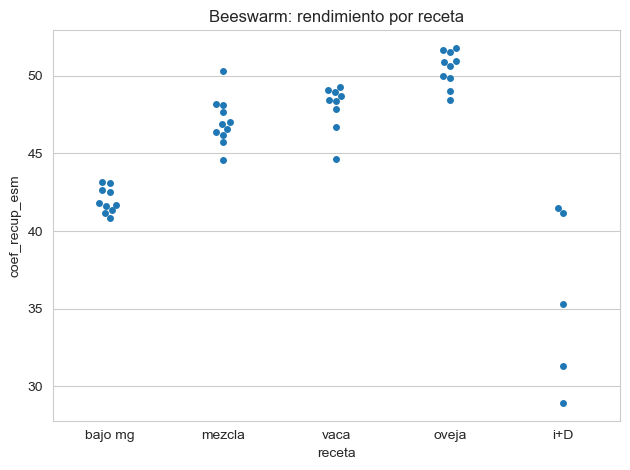

In [72]:
sns.swarmplot(data=df_sns, x='receta', y='coef_recup_esm', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: rendimiento por receta')
plt.tight_layout()
plt.show()

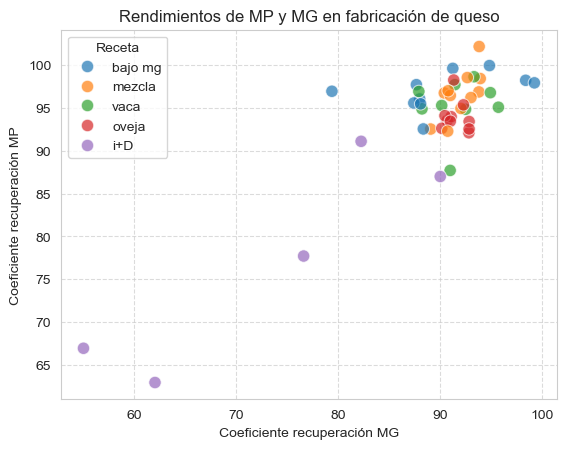

In [73]:
sns.scatterplot(data=df_sns, x='coef_recup_mg', y='coef_recup_mp', hue='receta', s=80, alpha=0.7)
plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Filtremos los resultados de i+D que no son relevantes para nuestro análisis y están distorionando la escala del gráfico.

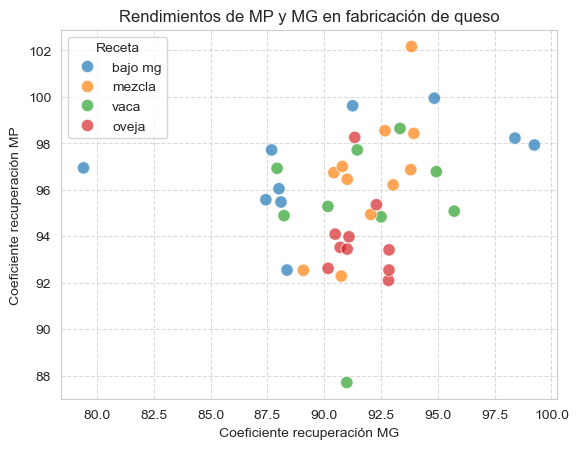

In [74]:
sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_mp', 
                hue='receta', 
                s=80, 
                alpha=0.7)
plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Calculemos los centroides de cada grupo (receta) mediante la mediana.

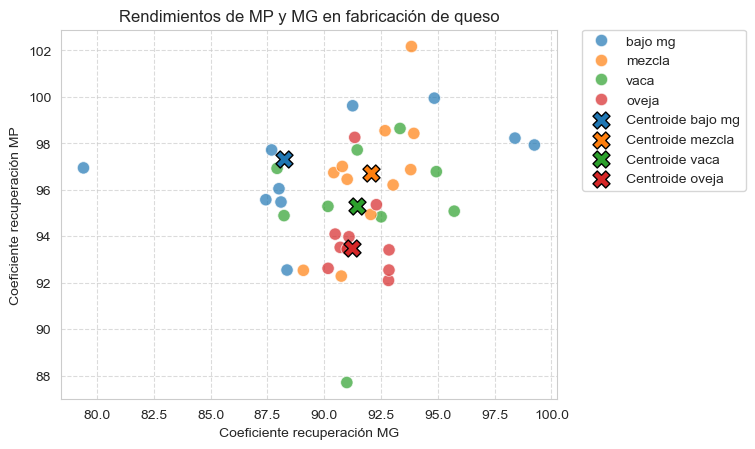

In [75]:

# Filtrar receta 'i+D'
df_filtrado = df[df['receta'] != 'i+D'].reset_index(drop=True)

# Crear paleta de colores por receta
recetas = df_filtrado['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_mp', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides_mg_mp = df.groupby('receta')[['coef_recup_mg', 'coef_recup_mp']].median()

for receta in recetas:
    centro = centroides_mg_mp.loc[receta]
    plt.scatter(
        centro['coef_recup_mg'],
        centro['coef_recup_mp'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación MP')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [76]:
print(centroides_mg_mp)

         coef_recup_mg  coef_recup_mp
receta                               
bajo mg      88.229046      97.329485
i+D          76.630772      77.697322
mezcla       92.047224      96.738573
oveja        91.215043      93.482273
vaca         91.451507      95.284041


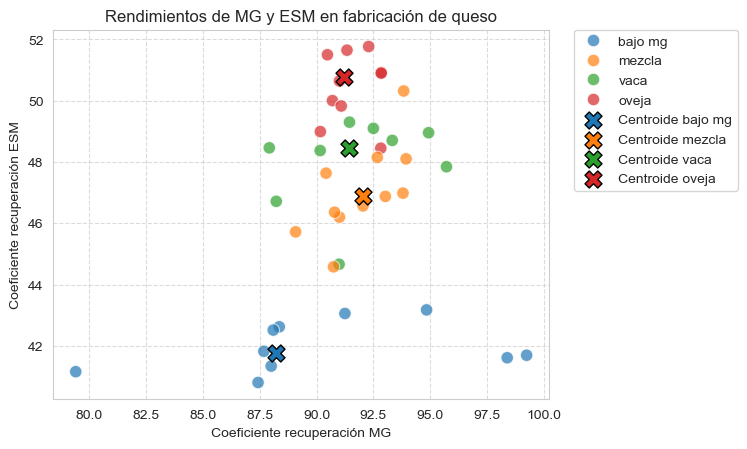

In [77]:
sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='coef_recup_mg', 
                y='coef_recup_esm', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides_mg_esm = df.groupby('receta')[['coef_recup_mg', 'coef_recup_esm']].median()

for receta in recetas:
    centro = centroides_mg_esm.loc[receta]
    plt.scatter(
        centro['coef_recup_mg'],
        centro['coef_recup_esm'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Rendimientos de MG y ESM en fabricación de queso')
plt.xlabel('Coeficiente recuperación MG')
plt.ylabel('Coeficiente recuperación ESM')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [78]:
print(centroides_mg_esm)

         coef_recup_mg  coef_recup_esm
receta                                
bajo mg      88.229046       41.760190
i+D          76.630772       35.290377
mezcla       92.047224       46.876581
oveja        91.215043       50.769829
vaca         91.451507       48.461305


Finalmente, aprovechamos nuestros cálculos para crear un documento con los rendimientos y el balance de materia de la fabricación, que exportaremos a un 'csv' y que podemos analizar sea en *python* o en Excel mediante tablas dinámicas.

In [79]:
### 5. Balance de Materia de pasteurizacion (Salida - Entrada)
# La falta de producto queda como negativo al hacer Salida - Entrada
df['balance_est_past'] = df['est_kg_cuba'] - df['est_kg_past']
df['balance_mg_past'] = df['mg_kg_cuba'] - df['mg_kg_past']
df['balance_mp_past'] = df['mp_kg_cuba'] - df['mp_kg_past']
df['balance_esm_past'] = df['esm_kg_cuba'] - df['esm_kg_past']

### 6. Balance de Materia de cubas (Salida - Entrada)
# La falta de producto queda como negativo al hacer Salida - Entrada
df['balance_est_cuba'] = df['est_kg_queso'] - df['est_kg_cuba']
df['balance_mg_cuba'] = df['mg_kg_queso'] - df['mg_kg_cuba']
df['balance_esm_cuba'] = df['esm_kg_queso'] - df['esm_kg_cuba'] - df['sal_kg_queso']

### 7. Preparación y Exportación del DataFrame de Resultados
# Columnas finales a incluir en el reporte
columnas_balance = [
    'fecha', 'receta', 'formato',
    'litros_past', 'peso_queso_total',
    'est_kg_past','est_kg_cuba', 'est_kg_queso', 
    'mg_kg_past','mg_kg_cuba', 'mg_kg_queso', 
    'mp_kg_past','mp_kg_cuba',
    'esm_kg_past','esm_kg_cuba', 'esm_kg_queso', 
    'balance_est_past', 'balance_mg_past', 'balance_mp_past', 'balance_esm_past',
    'balance_est_cuba', 'balance_mg_cuba', 'balance_esm_cuba',
    'coef_recup_mg', 'coef_recup_mp', 'coef_recup_esm',
    'consumo_mg_kg', 'consumo_mp_kg'
]

# Crear un nuevo DataFrame con las columnas de interés
df_balance = df[columnas_balance].copy()

# Guardar el DataFrame con punto decimal y separador ';'
nombre_archivo_salida = 'datos/informe_balance_materia.csv'

df_balance.to_csv(
    nombre_archivo_salida, 
    sep=';', 
    index=False,
    decimal=','
)


Veamos las características de los quesos.

In [21]:
df['esm_salida_salmuera'] = df['est_salida_salmuera']-df['mg_salida_salmuera']
df['hqd_salida_salmuera'] = (100 - df['est_salida_salmuera'])/(100 - df['mg_salida_salmuera']) * 100
df['ges_salida_salmuera'] = df['mg_salida_salmuera'] / df['est_salida_salmuera']

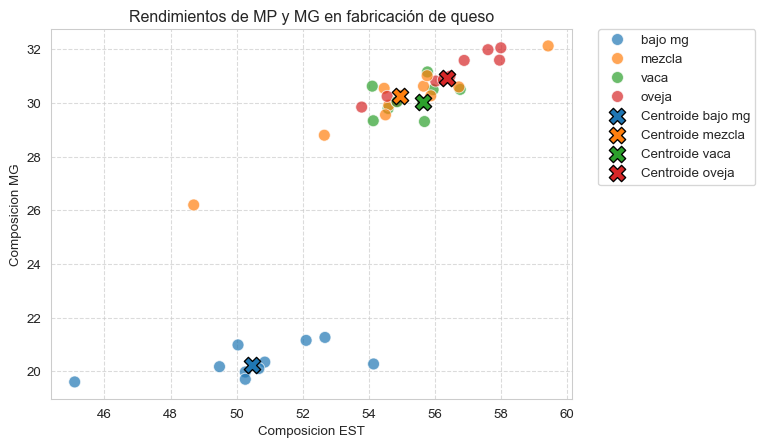

In [22]:

# Filtrar receta 'i+D'
df_filtrado = df[df['receta'] != 'i+D'].reset_index(drop=True)

# Crear paleta de colores por receta
recetas = df_filtrado['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='est_salida_salmuera', 
                y='mg_salida_salmuera', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides_est_mg = df.groupby('receta')[['est_salida_salmuera', 'mg_salida_salmuera']].median()

for receta in recetas:
    centro = centroides_est_mg.loc[receta]
    plt.scatter(
        centro['est_salida_salmuera'],
        centro['mg_salida_salmuera'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Rendimientos de MP y MG en fabricación de queso')
plt.xlabel('Composicion EST')
plt.ylabel('Composicion MG')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [23]:
print(centroides_est_mg)

         est_salida_salmuera  mg_salida_salmuera
receta                                          
bajo mg               50.465              20.220
i+D                   58.390              30.890
mezcla                54.950              30.280
oveja                 56.350              30.935
vaca                  55.630              30.050


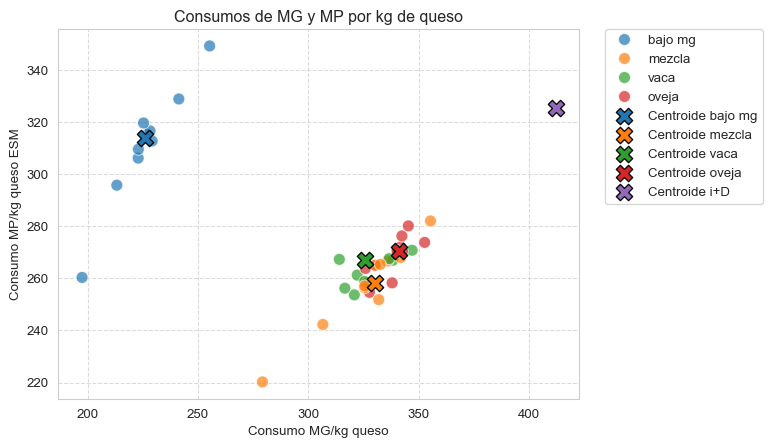

In [24]:
# Crear paleta de colores por receta
recetas = df['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='consumo_mg_kg', 
                y='consumo_mp_kg', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides_consumos_materia = df.groupby('receta')[['consumo_mg_kg', 'consumo_mp_kg']].median()

for receta in recetas:
    centro = centroides_consumos_materia.loc[receta]
    plt.scatter(
        centro['consumo_mg_kg'],
        centro['consumo_mp_kg'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Consumos de MG y MP por kg de queso')
plt.xlabel('Consumo MG/kg queso')
plt.ylabel('Consumo MP/kg queso ESM')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [25]:
print(centroides_consumos_materia)

         consumo_mg_kg  consumo_mp_kg
receta                               
bajo mg     226.119987     314.108816
i+D         411.975490     325.622549
mezcla      330.181811     258.288108
oveja       341.012161     270.611497
vaca        325.532130     266.991197


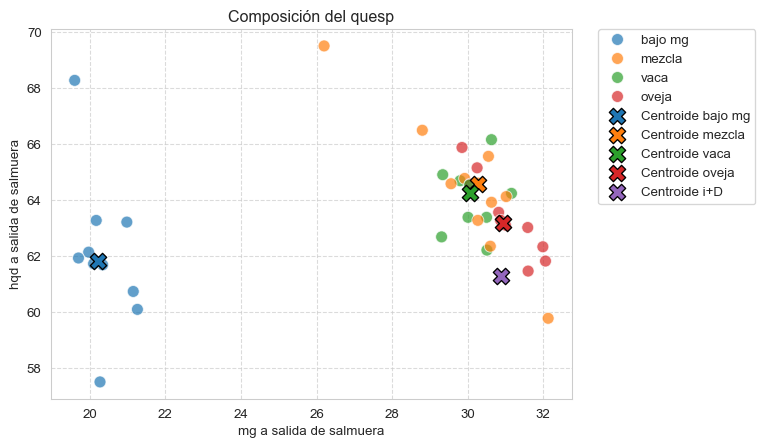

In [26]:
# Crear paleta de colores por receta
recetas = df['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

sns.scatterplot(data=df[df['receta'] != 'i+D'], 
                x='mg_salida_salmuera', 
                y='hqd_salida_salmuera', 
                hue='receta', 
                palette = color_dict,
                s=80, 
                # edgecolor = 'black',
                alpha=0.7)

# Calcular y dibujar centroides
centroides_consumos_materia = df.groupby('receta')[['mg_salida_salmuera', 'hqd_salida_salmuera']].median()

for receta in recetas:
    centro = centroides_consumos_materia.loc[receta]
    plt.scatter(
        centro['mg_salida_salmuera'],
        centro['hqd_salida_salmuera'],
        color=color_dict[receta],
        marker='X',
        s=150,
        edgecolor='black',
        label=f'Centroide {receta}'
    )

plt.title('Composición del quesp')
plt.xlabel('mg a salida de salmuera')
plt.ylabel('hqd a salida de salmuera')
plt.legend(title='Receta') # Mostrar leyenda para la especie
# Mover la leyenda fuera del gráfico
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

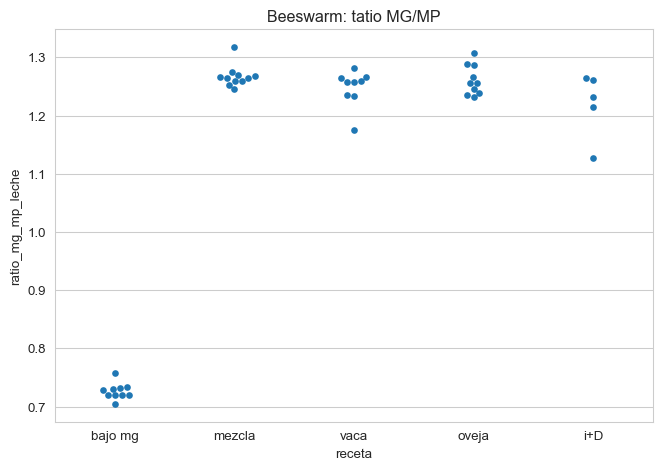

In [27]:
sns.swarmplot(data=df_sns, x='receta', y='ratio_mg_mp_leche', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: tatio MG/MP')
plt.tight_layout()
plt.show()

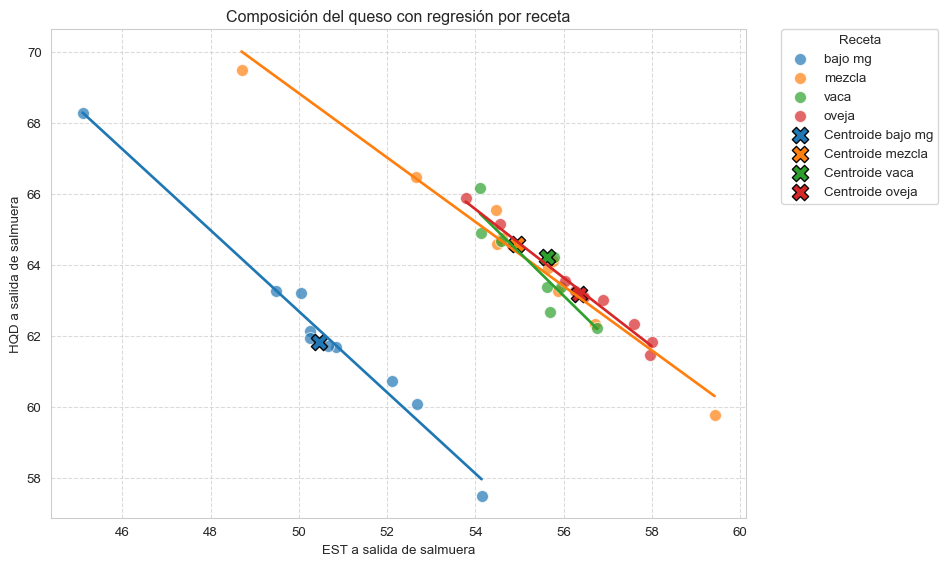

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar recetas excluidas
df_filtrado = df[df['receta'] != 'i+D'].copy()

# Crear paleta de colores por receta
recetas = df_filtrado['receta'].unique()
palette = sns.color_palette('tab10', n_colors=len(recetas))
color_dict = dict(zip(recetas, palette))

# Crear figura
plt.figure(figsize=(10, 6))

# Dibujar puntos y regresión por receta
for receta in recetas:
    datos = df_filtrado[df_filtrado['receta'] == receta]
    
    # Puntos
    sns.scatterplot(data=datos,
                    x='est_salida_salmuera',
                    y='hqd_salida_salmuera',
                    color=color_dict[receta],
                    s=80,
                    alpha=0.7,
                    label=receta)
    
    # Regresión
    sns.regplot(data=datos,
                x='est_salida_salmuera',
                y='hqd_salida_salmuera',
                scatter=False,
                ci=False,
                color=color_dict[receta],
                line_kws={'linewidth': 2})

# Calcular y dibujar centroides
centroides = df_filtrado.groupby('receta')[['est_salida_salmuera', 'hqd_salida_salmuera']].median()

for receta in recetas:
    centro = centroides.loc[receta]
    plt.scatter(centro['est_salida_salmuera'],
                centro['hqd_salida_salmuera'],
                color=color_dict[receta],
                marker='X',
                s=150,
                edgecolor='black',
                label=f'Centroide {receta}')

# Etiquetas y estilo
plt.title('Composición del queso con regresión por receta')
plt.xlabel('EST a salida de salmuera')
plt.ylabel('HQD a salida de salmuera')
plt.legend(title='Receta', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

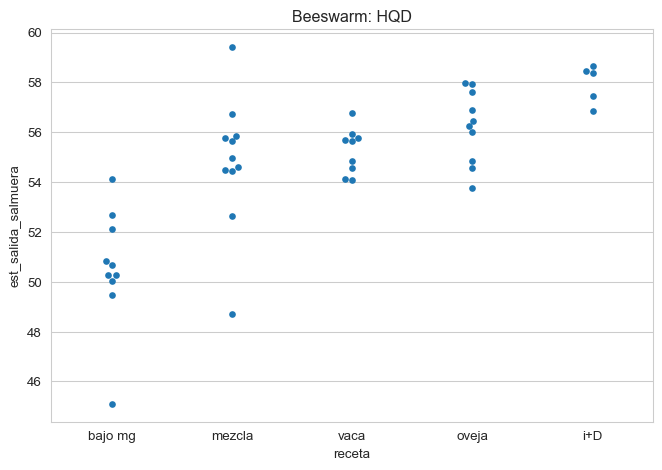

In [29]:
sns.swarmplot(data=df_sns, x='receta', y='est_salida_salmuera', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: HQD')
plt.tight_layout()
plt.show()

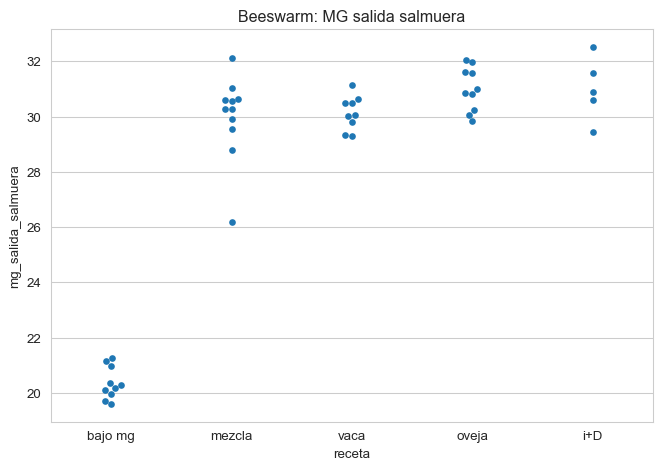

In [30]:
sns.swarmplot(data=df_sns, x='receta', y='mg_salida_salmuera', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: MG salida salmuera')
plt.tight_layout()
plt.show()

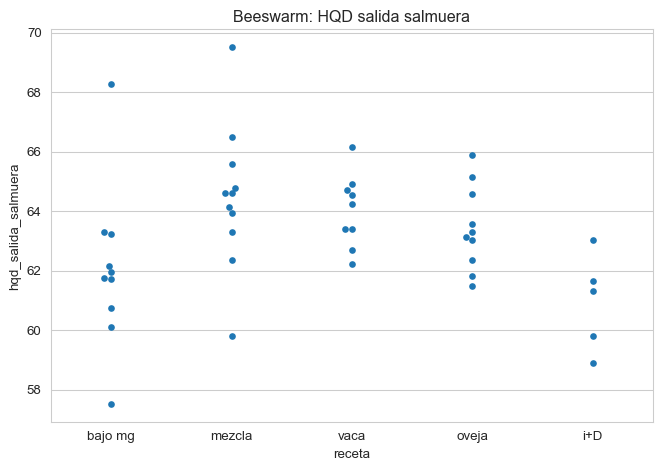

In [31]:
sns.swarmplot(data=df_sns, x='receta', y='hqd_salida_salmuera', size=5)
plt.xticks(rotation=0)
plt.title('Beeswarm: HQD salida salmuera')
plt.tight_layout()
plt.show()